# SpaceX S-1 — The DCF: turning the funding model into a share price

The four segment notebooks found the fundamentals; the integrated notebook stitched them into a single
funding equation. This notebook does the last step the others deliberately left alone: it puts a
**number on the equity** — a bear / base / bull **value per share** — and shows every link in the chain
so a reader can audit the price, not just trust it.

> **What a DCF is, in one paragraph (for the non-finance reader).** A company is worth the cash it will
> hand its owners over its life. A *discounted cash flow* model writes that down literally: forecast the
> free cash flow for a few years you can actually reason about (the **explicit period**, here
> FY2026–FY2030), add a **terminal value** for everything after (a single lump that stands in for the
> steady-state business), and **discount** both back to today — because a dollar in 2030 is worth less
> than a dollar now (you could have invested today's dollar instead). Sum those present values and you
> have the **enterprise value** (the whole operating business). Subtract net debt, divide by shares, and
> you have the **value per share**. That's the entire machine. Everything below is just doing it honestly.

**The chain, and where each piece comes from:**

| Step | What | Source |
|---|---|---|
| 1 | Explicit-period unlevered FCF, by segment, FY2026–FY2030 | `analysis/dcf.py` ← integrated model |
| 2 | Discount at **WACC** → present value | this notebook |
| 3 | **Terminal value** (normalized steady state; AI off the §6 frontier) | `dcf.py` |
| 4 | Sum → **enterprise value** (per segment) | `dcf.py` |
| 5 | − net debt → equity → ÷ shares → **per share** | `dcf.py` + `debt_schedule` / `capitalization` |
| 6 | **Bear / Base / Bull** headline + a WACC × growth sensitivity grid | this notebook |

**What we DEFER (on purpose), to keep this first read clean** — these are the follow-on steps:
- **Future equity raises / dilution.** The explicit period burns cash (integrated §5: ~\$78–96B in
  bear/base). Funding that issues shares. We value on *today's* pro-forma share count and treat the
  dilution path as a separate report step. **So these per-share numbers are pre-dilution — a ceiling.**
- **Cash taxes** (held at 0 — a \$41B accumulated deficit plus heavy D&A/R&D shields make near-zero cash
  tax defensible for years) and **depreciation refinement** beyond each segment model's own D&A.


## Setup — load the model and the valuation inputs

All the heavy lifting lives in `analysis/dcf.py` so this notebook can stay a narrated walkthrough. The **Space** segment uses `analysis.space_economics.project_space_forward` (built in `space.ipynb` §6–§7) — franchise revenue, Starship R&D commercialization, and modest external launch ramp. The
module reproduces the integrated notebook's Bear/Base/Bull **segment FCF paths** (it is now the canonical
home for that engine), then layers the valuation on top. Net debt and the pro-forma share count are read
straight from the validated S-1 CSVs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from analysis import charts, dcf

charts.apply_style()
COL = charts.SEGMENT_COLORS
SC  = {"Bear": "#c0392b", "Base": "#e07a3f", "Bull": "#2e9e8f"}   # scenario colors
fmtb = lambda x: f"${x/1000:+,.1f}B"     # $M -> signed $B
SCEN = ["Bear", "Base", "Bull"]

A   = dcf.default_assumptions()                  # base-case WACC/g, net debt + shares from CSVs
act = dcf._actuals()                             # FY2025 baselines, loaded once
RES = {s: dcf.value_scenario(s, A, actuals=act) for s in SCEN}

print(f"Valuation inputs (from the S-1):")
print(f"  Net debt (Mar-2026)   : ${A.net_debt/1000:,.1f}B   (total debt + finance leases − cash)")
print(f"  Pro-forma shares      : {A.shares_m:,.0f}M   (post preferred conversion, pre-IPO primary)")
print(f"  Base WACC / term. g   : {A.wacc:.0%} / {A.terminal_growth:.1%}   (cash tax {A.tax_rate:.0%}, NOL-shielded)\n")
print("Headline value per share:")
print(dcf.value_all(A).round(2).to_string())

Valuation inputs (from the S-1):
  Net debt (Mar-2026)   : $14.4B   (total debt + finance leases − cash)
  Pro-forma shares      : 12,520M   (post preferred conversion, pre-IPO primary)
  Base WACC / term. g   : 12% / 3.0%   (cash tax 0%, NOL-shielded)

Headline value per share:
      EV ($B)  Net debt ($B)  Equity ($B)  $/sh raw  $/sh floored  $/sh SOTP
Bear    10.78          14.41        -3.63     -0.29          0.00       4.37
Base   104.95          14.41        90.53      7.23          7.23      11.87
Bull   238.87          14.41       224.45     17.93         17.93      17.93


## Step 1 — The cash flows we're actually discounting

> **Free cash flow (FCF)**, plainly: the cash the business throws off after it pays to *build and replace*
> its own assets. We use **unlevered** FCF — before interest — so we're valuing the enterprise itself,
> independent of how it's financed: `op_income + D&A + SBC − capex`, summed across the three segments.
> (D&A and SBC are added back as non-cash charges; SBC's real cost re-appears later as **dilution**, which
> we deferred.)

These are the same Bear/Base/Bull segment paths the integrated notebook built — reproduced here as the
DCF's explicit-period input. The shape is the whole company in one frame: **Connectivity (teal) is the
only durable source of cash; AI (orange) is the furnace that eats it; Space (blue) is a rounding error
that mostly sets the clock.** This is what we now have to value.

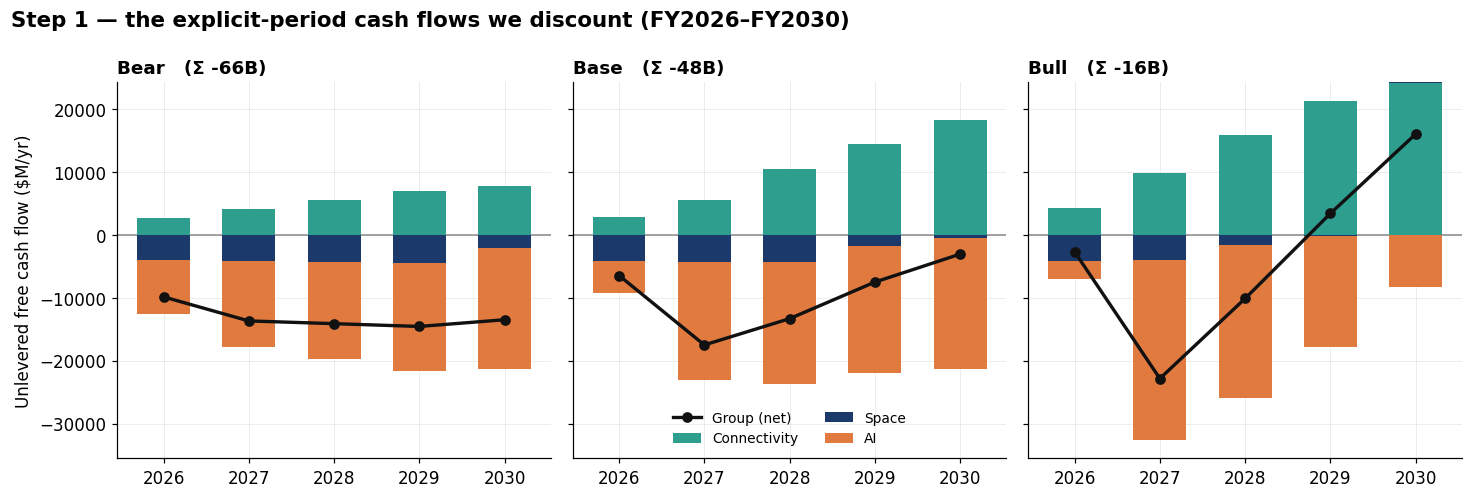

Group unlevered FCF ($M/yr):
         Bear     Base     Bull
2026  -9827.0  -6429.0  -2658.0
2027 -13652.0 -17472.0 -22816.0
2028 -14087.0 -13291.0 -10082.0
2029 -14531.0  -7475.0   3440.0
2030 -13463.0  -3027.0  16071.0


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)
for ax, s in zip(axes, SCEN):
    g = RES[s]["group"]; pos = np.zeros(5); neg = np.zeros(5)
    for nm in ["Connectivity", "Space", "AI"]:
        v = g[nm].values; p = np.clip(v, 0, None); n = np.clip(v, None, 0)
        ax.bar(dcf.YEARS, p, 0.62, bottom=pos, color=COL[nm], label=nm, zorder=3)
        ax.bar(dcf.YEARS, n, 0.62, bottom=neg, color=COL[nm], zorder=3)
        pos += p; neg += n
    ax.plot(dcf.YEARS, g["Group"].values, "o-", color="#111", lw=2.2, zorder=5, label="Group (net)")
    ax.axhline(0, color="#888", lw=1)
    ax.set_title(f"{s}   (Σ {g['Group'].sum()/1000:+.0f}B)", loc="left", fontsize=12)
    ax.set_xticks(dcf.YEARS)
axes[0].set_ylabel("Unlevered free cash flow ($M/yr)")
axes[1].legend(loc="lower center", ncol=2, fontsize=9)
fig.suptitle("Step 1 — the explicit-period cash flows we discount (FY2026–FY2030)",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95)); charts.save(fig, "dcf_step1_explicit_fcf"); plt.show()

print("Group unlevered FCF ($M/yr):")
print(pd.DataFrame({s: RES[s]["group"]["Group"] for s in SCEN}).round(0).to_string())

## Step 2 — Discounting: why a 2030 dollar isn't a 2026 dollar

> **WACC** (*weighted-average cost of capital*) is the single most important dial in any DCF, so define it
> plainly: it's the **annual return investors demand** for putting capital into this business given its
> risk — a blend of what lenders charge (cost of debt) and what equity holders expect (cost of equity),
> weighted by how much of each funds the company. It is the rate we **discount** future cash by. Higher
> WACC = future cash is worth less today = lower valuation.
>
> We use a single group **WACC = 12%**. That's a deliberate, defensible midpoint for an enterprise that is
> ~60%+ equity-funded with high equity risk but a monopoly cash core. (A purist would discount AI at a
> *higher* rate than Starlink — its cash is riskier — which would lower the value further; we test WACC
> sensitivity in Step 6 instead of hiding that judgment in segment rates.)

The mechanic: a cash flow `t` years out is worth `FCF / (1+WACC)^t` today. The **discount factor** falls
fast — at 12%, a 2030 dollar (t=5) is worth only ~57¢. The right panel shows what that does to the base
case: the same cash flows, before and after discounting.

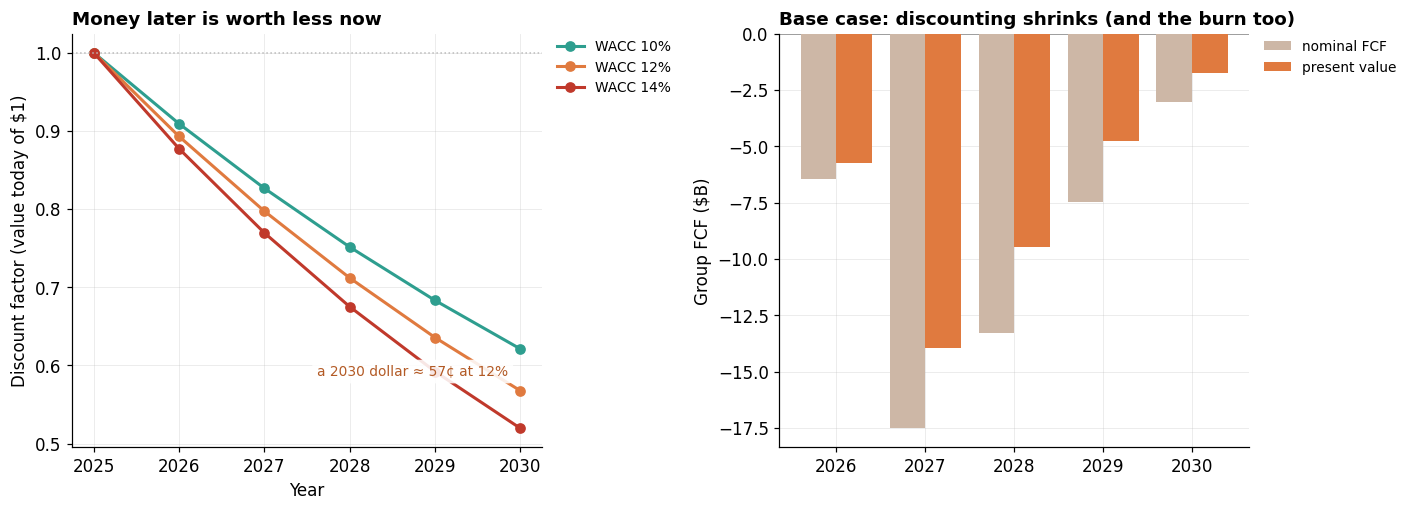

Discount factors (t=1..5 @ 12%): [0.893 0.797 0.712 0.636 0.567]


In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: the discount-factor curve at a few WACCs
t = np.arange(0, 6)
for w, c in [(0.10, "#2e9e8f"), (0.12, "#e07a3f"), (0.14, "#c0392b")]:
    axL.plot(2025 + t, 1 / (1 + w) ** t, "o-", color=c, lw=2, label=f"WACC {w:.0%}")
axL.axhline(1, color="#bbb", lw=1, ls=":")
charts.annotate_clear(axL, "a 2030 dollar ≈ 57¢ at 12%", (2030, 1 / 1.12 ** 5), textcoords="offset points",
             xytext=(-8, 10), ha="right", fontsize=9, color="#b35a25")
axL.set_xticks(2025 + t); axL.set_ylabel("Discount factor (value today of $1)")
axL.set_xlabel("Year"); axL.set_title("Money later is worth less now", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=9)

# Right: base-case nominal vs discounted group FCF
g = RES["Base"]["group"]["Group"].values
df = dcf.discount_factors(A.wacc, 5)
x = np.arange(5); w = 0.4
axR.bar(x - w/2, g/1000, w, color="#cdb7a6", label="nominal FCF", zorder=3)
axR.bar(x + w/2, g*df/1000, w, color="#e07a3f", label="present value", zorder=3)
axR.axhline(0, color="#888", lw=1); axR.set_xticks(x); axR.set_xticklabels(dcf.YEARS)
axR.set_ylabel("Group FCF ($B)"); axR.set_title("Base case: discounting shrinks (and the burn too)", loc="left", fontsize=12)
charts.legend_outside(axR, fontsize=9)
fig.tight_layout(); charts.save(fig, "dcf_step2_discounting"); plt.show()

print("Discount factors (t=1..5 @ 12%):", np.round(df, 3))

## Step 3 — Terminal value: the part that actually decides the answer

Five years is not the life of the business — it's barely the build-out. Everything after FY2030 is captured
in one number, the **terminal value (TV)**: the value, *as of 2030*, of all cash beyond it. With the
**Gordon growth** method,

$$\text{TV}_{2030} = \frac{\text{FCF}_{\text{normalized}}\times(1+g)}{\text{WACC}-g}$$

where `g` is the perpetual growth rate (we use **3%**, ~long-run nominal GDP — no company out-grows the
economy forever). Then we discount that lump back five years like any other cash flow.

**The one modeling choice that matters most.** You cannot Gordon-grow the *raw* FY2030 FCF — in FY2030 the
AI segment is still mid-build, capex bloated, FCF deeply negative; perpetuity-growing that is nonsense. So
each segment gets a **normalized steady-state** terminal FCF:
- **Connectivity / Space** — their FY2030 run-rate (by then capex has glided down to maintenance).
- **AI — taken straight off the integrated §6 feasibility frontier**: the *mature, done-growing* fleet
  whose only capex is chip **refresh**. That is the honest question — *once it stops growing, does the GPU
  fleet cover its own refresh + power + R&D?* — and it is **floored at zero** (the **abandonment option**:
  a fleet that can't cover its own refresh simply isn't refreshed; you run the chips to end-of-life and
  stop — you don't burn cash into perpetuity).

This is why the integrated hand-off said *"terminal value turns on whether AI ever clears the frontier."*
It literally does. The chart shows each segment's normalized terminal FCF; AI only clears zero in the Bull.

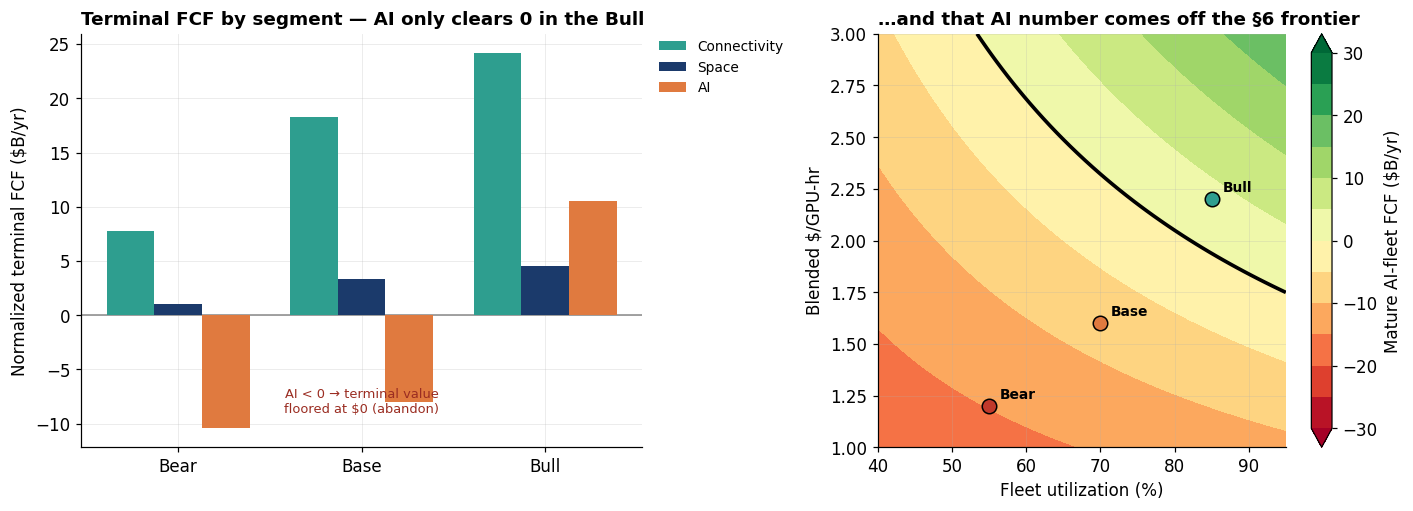

Normalized terminal FCF ($B/yr) and resulting terminal value (PV today, $B):
  Bear: FCF {'Connectivity': 7.8, 'Space': 1.0, 'AI': -10.4}  ->  Σ terminal PV $57B
  Base: FCF {'Connectivity': 18.3, 'Space': 3.4, 'AI': -8.0}  ->  Σ terminal PV $141B
  Bull: FCF {'Connectivity': 24.2, 'Space': 4.6, 'AI': 10.5}  ->  Σ terminal PV $255B


In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})

# Left: normalized terminal FCF by segment, per scenario
x = np.arange(3); w = 0.26
for j, nm in enumerate(["Connectivity", "Space", "AI"]):
    vals = [RES[s]["terminal_fcf"][nm] / 1000 for s in SCEN]
    axL.bar(x + (j - 1) * w, vals, w, color=COL[nm], label=nm, zorder=3)
axL.axhline(0, color="#888", lw=1); axL.set_xticks(x); axL.set_xticklabels(SCEN)
axL.set_ylabel("Normalized terminal FCF ($B/yr)")
axL.set_title("Terminal FCF by segment — AI only clears 0 in the Bull", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=9)
axL.annotate("AI < 0 → terminal value\nfloored at $0 (abandon)", (1, -9), fontsize=8.5,
             color="#9b2d22", ha="center")

# Right: the AI mature-fleet frontier — where each scenario's terminal AI sits
util_ax = np.linspace(0.40, 0.95, 60); price_ax = np.linspace(1.0, 3.0, 60)
U, P = np.meshgrid(util_ax, price_ax)
Z = np.vectorize(lambda u, p: dcf.ai_mature_fcf("Base", util=u, price=p) / 1000)(U, P)
cf = axR.contourf(U * 100, P, Z, levels=np.arange(-30, 31, 5), cmap="RdYlGn", extend="both")
axR.contour(U * 100, P, Z, levels=[0], colors="k", linewidths=2.4)
fig.colorbar(cf, ax=axR, label="Mature AI-fleet FCF ($B/yr)")
for s, (u, p) in zip(SCEN, [(.55, 1.2), (.70, 1.6), (.85, 2.2)]):
    axR.scatter([u * 100], [p], s=90, color=SC[s], edgecolor="k", zorder=6)
    axR.annotate(s, (u * 100, p), textcoords="offset points", xytext=(7, 5), fontsize=9, fontweight="bold")
axR.set_xlabel("Fleet utilization (%)"); axR.set_ylabel("Blended $/GPU-hr")
axR.set_title("…and that AI number comes off the §6 frontier", loc="left", fontsize=12)
fig.tight_layout(); charts.save(fig, "dcf_step3_terminal"); plt.show()

print("Normalized terminal FCF ($B/yr) and resulting terminal value (PV today, $B):")
for s in SCEN:
    r = RES[s]
    tf = {k: round(v/1000, 1) for k, v in r["terminal_fcf"].items()}
    tv = sum(r["terminal_pv"].values()) / 1000
    print(f"  {s:4}: FCF {tf}  ->  Σ terminal PV ${tv:.0f}B")

## Step 4 — Assemble the enterprise value

Now add it up. Each segment's **enterprise value** is its discounted explicit-period FCF **plus** its
discounted terminal value. The group EV is the sum. Splitting each bar into *explicit* (the FY2026–30 cash)
vs *terminal* (everything after) makes the engine visible: **almost all the value is Connectivity's
terminal** — the steady-state Starlink annuity — while **AI's explicit period is a deep negative** (the
build burns cash for years) that only the Bull's positive terminal repays.

This is the valuation's honest signature: you are not buying today's cash flows (they're negative); you are
buying the *bet* that Starlink's annuity is huge and that AI eventually stops bleeding.

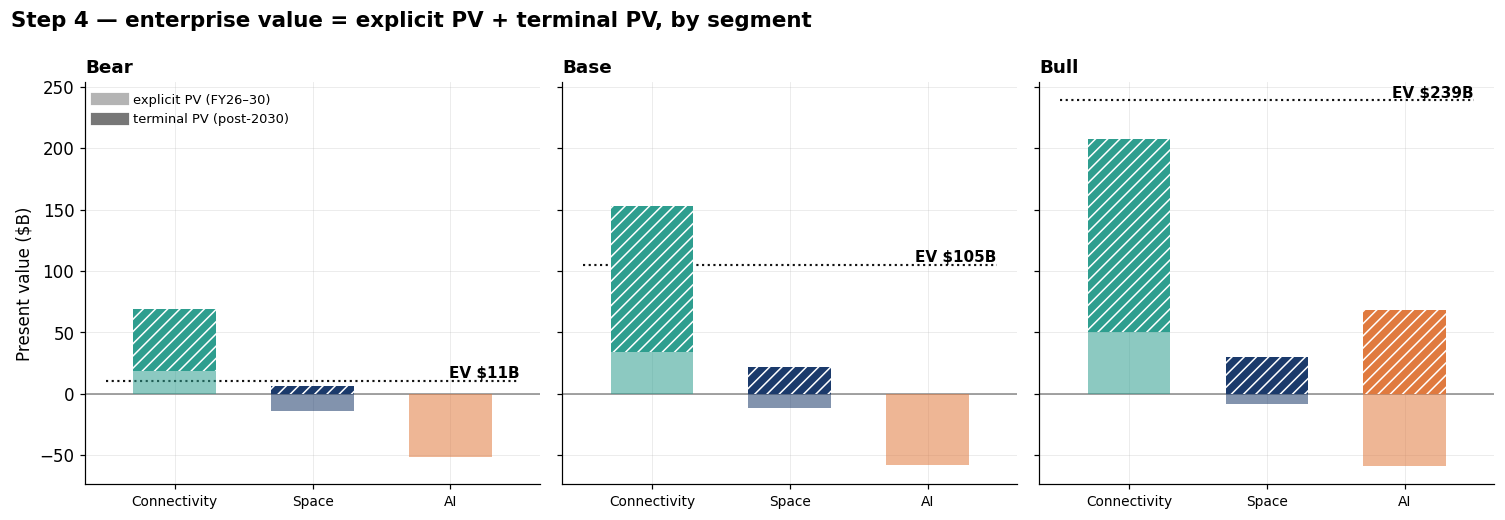

Enterprise value build ($B):
  Bear: EV   10.8  =  Conn +69  Spac -7  AI -51
  Base: EV  104.9  =  Conn +153  Spac +10  AI -58
  Bull: EV  238.9  =  Conn +208  Spac +22  AI +10


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.8), sharey=True)
for ax, s in zip(axes, SCEN):
    r = RES[s]; segs = ["Connectivity", "Space", "AI"]
    expl = np.array([r["explicit_pv"][k] for k in segs]) / 1000
    term = np.array([r["terminal_pv"][k] for k in segs]) / 1000
    xs = np.arange(3)
    ax.bar(xs, expl, 0.6, color=[COL[k] for k in segs], alpha=0.55, zorder=3, label="explicit PV (FY26–30)")
    ax.bar(xs, term, 0.6, bottom=np.clip(expl, 0, None), color=[COL[k] for k in segs], zorder=3,
           hatch="///", edgecolor="white", linewidth=0, label="terminal PV (post-2030)")
    ax.axhline(0, color="#888", lw=1)
    ax.plot([-0.5, 2.5], [r["ev_total"]/1000]*2, ":", color="#111", lw=1.4)
    ax.annotate(f"EV ${r['ev_total']/1000:.0f}B", (2.5, r["ev_total"]/1000), ha="right",
                va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(xs); ax.set_xticklabels(segs, fontsize=9)
    ax.set_title(f"{s}", loc="left", fontsize=12)
axes[0].set_ylabel("Present value ($B)")
axes[0].legend(handles=[Line2D([0],[0], color="#777", lw=8, alpha=0.55, label="explicit PV (FY26–30)"),
                        Line2D([0],[0], color="#777", lw=8, label="terminal PV (post-2030)")],
               fontsize=8.5, loc="upper left")
fig.suptitle("Step 4 — enterprise value = explicit PV + terminal PV, by segment",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95)); charts.save(fig, "dcf_step4_ev_buildup"); plt.show()

print("Enterprise value build ($B):")
for s in SCEN:
    r = RES[s]
    print(f"  {s:4}: EV {r['ev_total']/1000:6.1f}  =  "
          + "  ".join(f"{k[:4]} {r['ev'][k]/1000:+.0f}" for k in ['Connectivity','Space','AI']))

## Step 5 — From enterprise value to a share price

The EV is the value of the *operating business*. Shareholders own what's left after the lenders are paid,
spread across the shares outstanding:

$$\text{equity} = \text{EV} - \text{net debt}, \qquad \text{per share} = \frac{\text{equity}}{\text{shares}}$$

- **Net debt** = total debt + finance leases − cash = **\$14.4B** (Mar-2026; includes the \$20B bridge
  still outstanding at the valuation date — its IPO repayment is part of the deferred dilution step).
- **Shares** = **12,520M** pro-forma, the post-conversion count from the capitalization table (preferred has
  become common; Class C folded into Class A) — but *before* the IPO's new primary shares. So this is a
  **pre-dilution** per-share: a ceiling that the follow-on raise step will pull down.

The waterfall makes the bridge literal for the base case; the table runs all three.

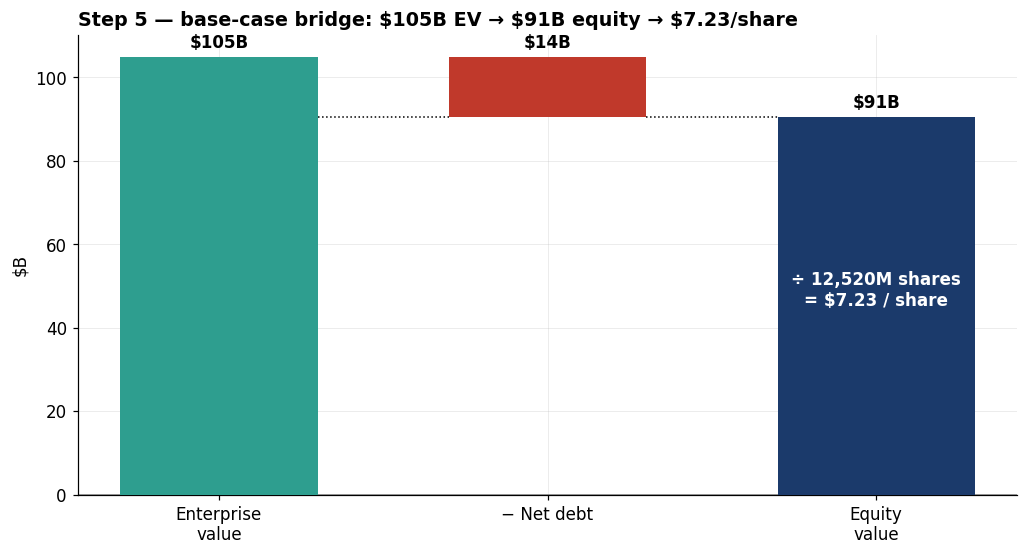

EV → equity → per share ($B except per-share):
      EV ($B)  Net debt ($B)  Equity ($B)  $/sh raw  $/sh floored  $/sh SOTP
Bear    10.78          14.41        -3.63     -0.29          0.00       4.37
Base   104.95          14.41        90.53      7.23          7.23      11.87
Bull   238.87          14.41       224.45     17.93         17.93      17.93


In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
r = RES["Base"]
ev = r["ev_total"]/1000; nd = r["net_debt"]/1000; eq = r["equity_value"]/1000
steps  = ["Enterprise\nvalue", "− Net debt", "Equity\nvalue"]
bottoms = [0, eq, 0]; heights = [ev, nd, eq]
colors  = ["#2e9e8f", "#c0392b", "#1b3a6b"]
for i, (b, h, c) in enumerate(zip(bottoms, heights, colors)):
    ax.bar(i, h, 0.6, bottom=b, color=c, zorder=3)
    ax.annotate(f"${ev if i==0 else nd if i==1 else eq:,.0f}B", (i, b + h),
                textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
ax.plot([0.3, 0.7], [eq, eq], "k:", lw=1); ax.plot([1.3, 1.7], [eq, eq], "k:", lw=1)
ax.set_xticks(range(3)); ax.set_xticklabels(steps)
ax.set_ylabel("$B"); ax.axhline(0, color="#888", lw=1)
ax.set_title(f"Step 5 — base-case bridge: ${ev:,.0f}B EV → ${eq:,.0f}B equity → "
             f"${r['per_share']:.2f}/share", loc="left", fontsize=12.5)
ax.annotate(f"÷ {A.shares_m:,.0f}M shares\n= ${r['per_share']:.2f} / share", (2, eq*0.5),
            ha="center", fontsize=11, color="white", fontweight="bold")
charts.finish(fig); charts.save(fig, "dcf_step5_equity_bridge", layout=False); plt.show()

print("EV → equity → per share ($B except per-share):")
print(dcf.value_all(A).round(2).to_string())

## Step 5b — Dilution: the cost of funding the furnace (ownership ≠ value)

The per-share numbers so far are **pre-dilution**. The base/bear cases burn cash, and funding that burn
means issuing stock — so before we hand a number to a buyer, we account for the new shares.

> **The subtlety almost everyone gets wrong.** It's tempting to just subtract the ~\$78–96B raise from
> equity value. **Don't — that double-counts.** The burn is *already* inside the DCF (it's the negative
> explicit-period FCF that EV is net of). Raising equity *at fair value* to fund it is NPV-neutral — \$1 of
> cash in, \$1 of stock out — so it shrinks each holder's **ownership %**, but **not** the intrinsic
> **value per share**. The *only* genuine per-share value haircut is what you give away by issuing **below**
> fair value (IPO pop, follow-on/down-round discount) plus fees — modeled here as ~15% discount + 4% fees
> on the **equity portion** (~80%) of the gap.

So dilution is really *two* quantities, and they're wildly different:
- **Ownership sold** (large): new shares ÷ total. Keeping AI, the base case **sells ~45% of the company**.
- **Value-per-share haircut** (small): the discount + fee transfer to new holders — base-keep ≈ −15%.

And because the gap is *driven by AI capex*, dilution sharpens the keep-vs-abandon fork from Step 6 — the
funding gap is, almost entirely, **the cost of keeping the AI furnace lit**:
- **Keep AI (fund it):** Base \$7.23 → **\$6.16** (sell 45%); Bull \$17.93 → **\$17.29** (sell ~16%);
  **Bear wipes out** — there is no positive equity to raise ~\$77B against, so current holders cede ~all of it.
- **Abandon AI (keep Starlink):** the gap collapses to ~the bridge, Starlink self-funds, so **Base stays
  undiluted at \$11.87** and Bear gives up only ~7%.

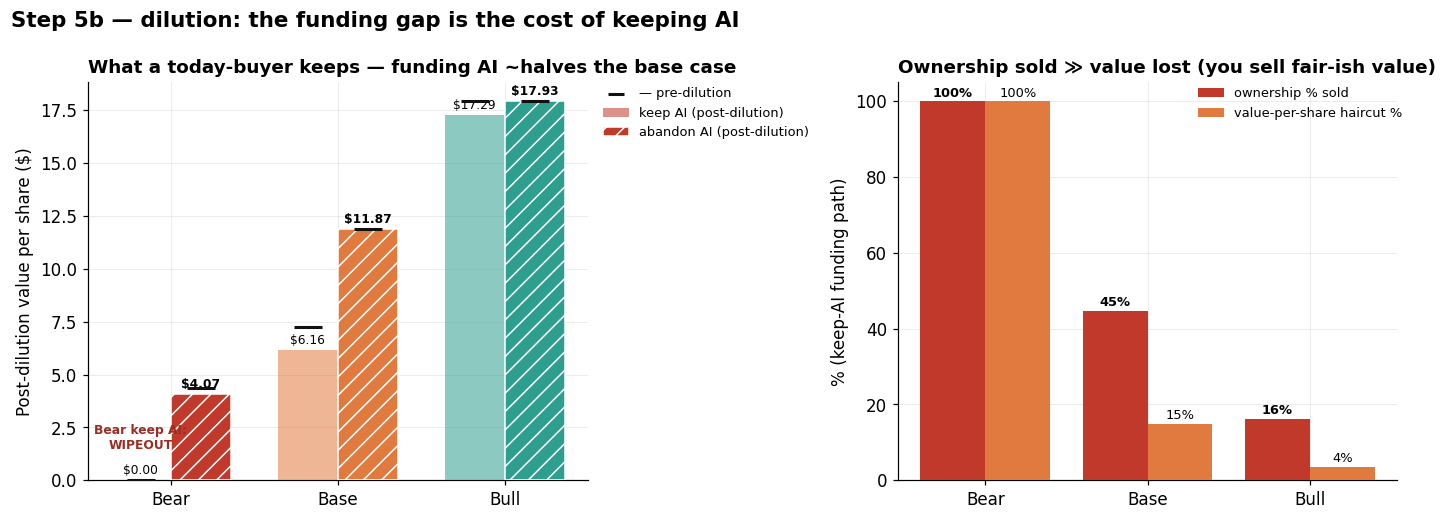

Dilution — pre -> post per share ($), by AI decision:
  keep AI    Bear: $ 0.00 -> $ 0.00  (raise $  76B; WIPEOUT)
  keep AI    Base: $ 7.23 -> $ 6.16  (raise $  62B; sell 45%, -15% val)
  keep AI    Bull: $17.93 -> $17.29  (raise $  37B; sell 16%, -4% val)
  abandon AI Bear: $ 4.37 -> $ 4.07  (raise $  17B; sell 27%, -7% val)
  abandon AI Base: $11.87 -> $11.87  (raise $   0B; sell 0%, -0% val)
  abandon AI Bull: $17.93 -> $17.93  (raise $   0B; sell 0%, -0% val)


In [7]:
da = dcf.DilutionAssumptions()
DIL = {b: {s: dcf.dilution(s, A, da, basis=b, actuals=act) for s in SCEN}
       for b in ["floored", "sotp"]}      # floored = keep AI ; sotp = abandon AI

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(3); w = 0.36

# Left: post-dilution $/sh, keep AI vs abandon AI, with pre-dilution ghost marks
keep_post = [DIL["floored"][s]["post_ps"] for s in SCEN]
ab_post   = [DIL["sotp"][s]["post_ps"]    for s in SCEN]
keep_pre  = [max(0, RES[s]["per_share"])  for s in SCEN]
ab_pre    = [RES[s]["per_share_sotp"]     for s in SCEN]
axL.bar(x - w/2, keep_post, w, color=[SC[s] for s in SCEN], alpha=0.55, zorder=3, label="keep AI (post-dilution)")
axL.bar(x + w/2, ab_post,   w, color=[SC[s] for s in SCEN], zorder=3, hatch="//", edgecolor="white",
        label="abandon AI (post-dilution)")
axL.scatter(x - w/2, keep_pre, marker="_", s=320, color="#111", lw=2, zorder=5)
axL.scatter(x + w/2, ab_pre,   marker="_", s=320, color="#111", lw=2, zorder=5)
axL.scatter([], [], marker="_", s=120, color="#111", lw=2, label="— pre-dilution")
axL.annotate("Bear keep AI:\nWIPEOUT", (-w/2, 0.2), textcoords="offset points", xytext=(0, 18),
             ha="center", fontsize=8, color="#9b2d22", fontweight="bold")
for i in range(3):
    axL.annotate(f"${keep_post[i]:.2f}", (i - w/2, keep_post[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8)
    axL.annotate(f"${ab_post[i]:.2f}", (i + w/2, ab_post[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8, fontweight="bold")
axL.set_xticks(x); axL.set_xticklabels(SCEN); axL.set_ylabel("Post-dilution value per share ($)")
axL.set_title("What a today-buyer keeps — funding AI ~halves the base case", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=8.5, loc="upper left")# Right: ownership sold vs value haircut (keep-AI world) — the dissociation
own = [DIL["floored"][s]["ownership_sold"] * 100 for s in SCEN]
val = [DIL["floored"][s]["value_haircut_pct"] * 100 for s in SCEN]
axR.bar(x - 0.2, own, 0.4, color="#c0392b", zorder=3, label="ownership % sold")
axR.bar(x + 0.2, val, 0.4, color="#e07a3f", zorder=3, label="value-per-share haircut %")
for i in range(3):
    axR.annotate(f"{own[i]:.0f}%", (i - 0.2, own[i]), textcoords="offset points", xytext=(0, 3),
                 ha="center", fontsize=8.5, fontweight="bold")
    axR.annotate(f"{val[i]:.0f}%", (i + 0.2, val[i]), textcoords="offset points", xytext=(0, 3),
                 ha="center", fontsize=8.5)
axR.set_xticks(x); axR.set_xticklabels(SCEN); axR.set_ylabel("% (keep-AI funding path)")
axR.set_title("Ownership sold ≫ value lost (you sell fair-ish value)", loc="left", fontsize=12)
charts.legend_outside(axR, fontsize=8.5, loc="upper right")
fig.suptitle("Step 5b — dilution: the funding gap is the cost of keeping AI",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95)); charts.save(fig, "dcf_step5b_dilution"); plt.show()

print("Dilution — pre -> post per share ($), by AI decision:")
for b, lbl in [("floored", "keep AI   "), ("sotp", "abandon AI")]:
    for s in SCEN:
        d = DIL[b][s]
        tag = "WIPEOUT" if d["wipeout"] else f"sell {d['ownership_sold']:.0%}, -{d['value_haircut_pct']:.0%} val"
        print(f"  {lbl} {s:4}: ${d['pre_ps']:5.2f} -> ${d['post_ps']:5.2f}  "
              f"(raise ${d['equity_raise']/1000:4.0f}B; {tag})")

## Step 6 — The headline, floored: bear / base / bull

The raw DCF prints a bear of **essentially zero (−\$0.29/share)**: AI's −\$51B own-DCF very nearly cancels
the ~\$69B of Starlink plus a (slightly negative) Space beneath it, leaving EV (~\$11B) a hair *below* net
debt (\$14.4B). So the bear sits right on the insolvency line — a knife-edge, not a price. Two honest reads
pull it apart:

1. **Limited liability.** Equity is a call option on the enterprise; it can't be worth less than zero. The
   small negative just flags *modeled insolvency on the bear path* (EV below net debt), not a sub-zero stock —
   so we floor it at \$0.
2. **Abandonment (sum-of-the-parts).** The raw bear assumes management keeps pouring cash into an AI
   segment whose own DCF is **−\$51B**. A rational owner doesn't — and integrated §8 showed they *can't*
   (the burn is self-limiting; capital throttles it). Floor each value-destroying segment at zero and the
   company is worth at least its **surviving parts** — in the bear, essentially **standalone Starlink
   (~\$55B equity, ~\$4.37/share)**. *That* is the real bear floor.

Each scenario is therefore a **range**, and the chart shows both ends — **"keep" (raw, floored)** vs
**"abandon AI" (SOTP)**. They converge in the **Bull**, where AI is NPV-*positive* (so you'd never abandon
it) — note the Bull's Connectivity is now the **§7.7 affordability-cost flywheel** (ARPU falls to \$38, subs
reach ~64M, margin *computed* at ~58%): a more internally-consistent optimistic case than a hand-dialed
high-ARPU/high-subs bull, which is *why* the bull lands at ~\$18 rather than a naive ~\$28 — lower, but
defensible. The dashed purple line is the probability-weighted blend (25/50/25). And the ~\$350B private
mark (≈\$28/sh) now sits **above even the bull** — the gap is what the market pays for the AI option.

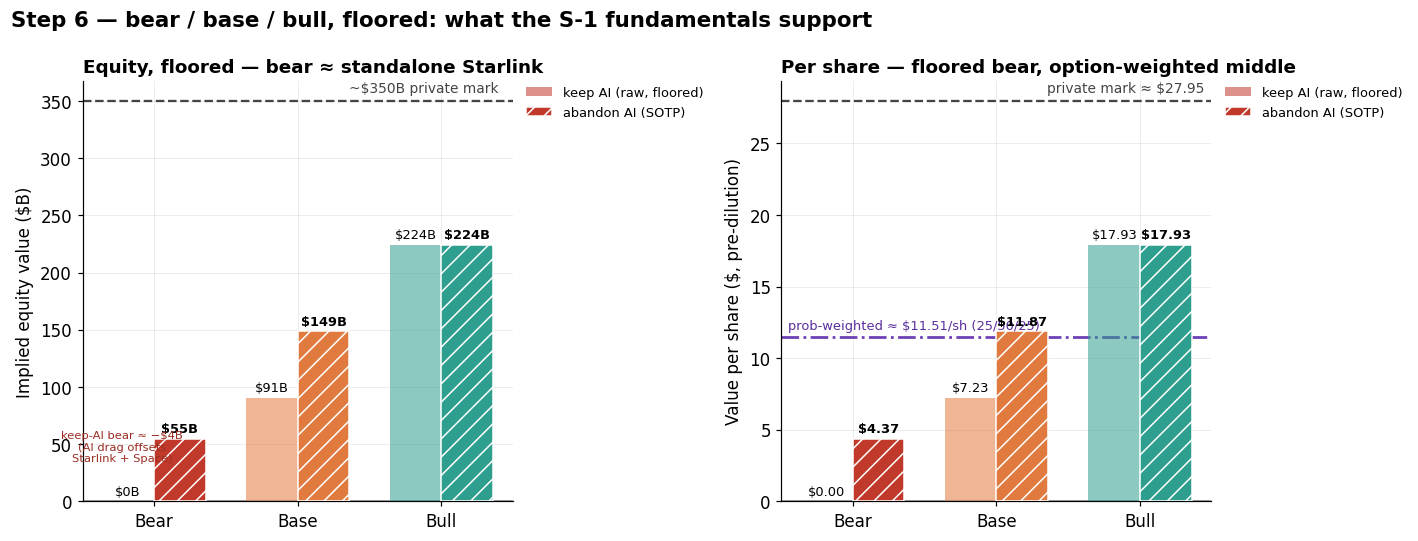

Per-share, keep (raw, floored) -> abandon-AI (SOTP):
  Bear: $ 0.00  ->  $ 4.37   (equity $0B -> $55B; raw -0.29)
  Base: $ 7.23  ->  $11.87   (equity $91B -> $149B; raw +7.23)
  Bull: $17.93  ->  $17.93   (equity $224B -> $224B; raw +17.93)
  prob-weighted (25/50/25, SOTP): $144B -> $11.51/sh
  private mark ~$350B -> $27.95/sh (≈ bull)


In [8]:
PRIVATE_MARK_EQUITY_B = 350.0    # external reference point (recent private rounds), NOT from the S-1
pm_ps = PRIVATE_MARK_EQUITY_B * 1000 / A.shares_m
exp = dcf.expected_value(a=A, basis="sotp")          # prob-weighted, abandonment-floored

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
w = 0.36; x = np.arange(3)

# Left: equity value — "keep" (raw, floored) vs "abandon AI" (SOTP)
eq_keep = [max(0, RES[s]["equity_value"]) / 1000 for s in SCEN]
eq_sotp = [RES[s]["equity_sotp"] / 1000 for s in SCEN]
axL.bar(x - w/2, eq_keep, w, color=[SC[s] for s in SCEN], alpha=0.55, zorder=3, label="keep AI (raw, floored)")
axL.bar(x + w/2, eq_sotp, w, color=[SC[s] for s in SCEN], zorder=3, hatch="//", edgecolor="white",
        label="abandon AI (SOTP)")
axL.axhline(PRIVATE_MARK_EQUITY_B, color="#444", ls="--", lw=1.5)
axL.annotate(f"~${PRIVATE_MARK_EQUITY_B:.0f}B private mark", (2.4, PRIVATE_MARK_EQUITY_B + 8),
             ha="right", fontsize=9, color="#444")
for i in range(3):
    axL.annotate(f"${eq_keep[i]:,.0f}B", (i - w/2, eq_keep[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5)
    axL.annotate(f"${eq_sotp[i]:,.0f}B", (i + w/2, eq_sotp[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5, fontweight="bold")
axL.annotate("keep-AI bear ≈ −$4B\n(AI drag offsets\nStarlink + Space)", (-w/2, 0), textcoords="offset points",
             xytext=(-4, 26), ha="center", fontsize=7.5, color="#9b2d22")
axL.axhline(0, color="#888", lw=1); axL.set_xticks(x); axL.set_xticklabels(SCEN)
axL.set_ylabel("Implied equity value ($B)")
axL.set_title("Equity, floored — bear ≈ standalone Starlink", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=8.5, loc="upper left")# Right: per share, same two reads + prob-weighted + private mark
ps_keep = [max(0, RES[s]["per_share"]) for s in SCEN]
ps_sotp = [RES[s]["per_share_sotp"] for s in SCEN]
axR.bar(x - w/2, ps_keep, w, color=[SC[s] for s in SCEN], alpha=0.55, zorder=3, label="keep AI (raw, floored)")
axR.bar(x + w/2, ps_sotp, w, color=[SC[s] for s in SCEN], zorder=3, hatch="//", edgecolor="white",
        label="abandon AI (SOTP)")
axR.axhline(exp["per_share"], color="#6c3fb5", ls="-.", lw=1.8)
axR.annotate(f"prob-weighted ≈ ${exp['per_share']:.2f}/sh (25/50/25)", (-0.45, exp["per_share"]),
             textcoords="offset points", xytext=(0, 5), fontsize=8.5, color="#5a2e9e")
axR.axhline(pm_ps, color="#444", ls="--", lw=1.5)
axR.annotate(f"private mark ≈ ${pm_ps:.2f}", (2.45, pm_ps + 0.6), ha="right", fontsize=9, color="#444")
for i in range(3):
    axR.annotate(f"${ps_keep[i]:.2f}", (i - w/2, ps_keep[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5)
    axR.annotate(f"${ps_sotp[i]:.2f}", (i + w/2, ps_sotp[i]), textcoords="offset points",
                 xytext=(0, 4), ha="center", fontsize=8.5, fontweight="bold")
axR.axhline(0, color="#888", lw=1); axR.set_xticks(x); axR.set_xticklabels(SCEN)
axR.set_ylabel("Value per share ($, pre-dilution)")
axR.set_title("Per share — floored bear, option-weighted middle", loc="left", fontsize=12)
charts.legend_outside(axR, fontsize=8.5, loc="upper left")
fig.suptitle("Step 6 — bear / base / bull, floored: what the S-1 fundamentals support",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95)); charts.save(fig, "dcf_step6_headline"); plt.show()

print("Per-share, keep (raw, floored) -> abandon-AI (SOTP):")
for s in SCEN:
    print(f"  {s:4}: ${max(0, RES[s]['per_share']):5.2f}  ->  ${RES[s]['per_share_sotp']:5.2f}   "
          f"(equity ${max(0,RES[s]['equity_value'])/1000:.0f}B -> ${RES[s]['equity_sotp']/1000:.0f}B; "
          f"raw {RES[s]['per_share']:+.2f})")
print(f"  prob-weighted (25/50/25, SOTP): ${exp['equity']/1000:.0f}B -> ${exp['per_share']:.2f}/sh")
print(f"  private mark ~${PRIVATE_MARK_EQUITY_B:.0f}B -> ${pm_ps:.2f}/sh (≈ bull)")

## Step 7 — How fragile is the number? WACC × terminal-growth

A DCF's two most arbitrary inputs are **WACC** and **terminal growth `g`** — and the terminal value
amplifies both (it divides by `WACC − g`, so small moves swing it hard). The grid below re-runs the full
model across a band of each, for the base and bull cases, so the reader can see the **range**, not a false-
precision point estimate. The takeaway is less the exact cell than the **gradient**: the base case stays in
the single-digits-per-share across the whole grid, while the bull is genuinely sensitive — its big positive
terminal magnifies every assumption.

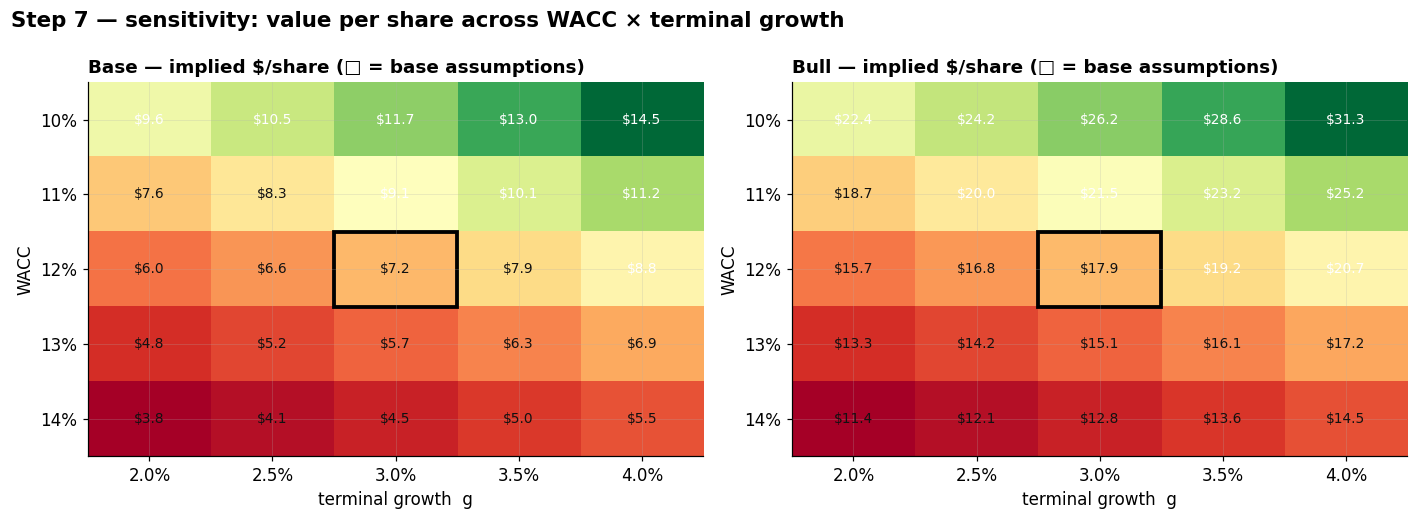

Base-case per-share sensitivity ($/share):
     2.0%   2.5%   3.0%   3.5%   4.0%
10%  9.56  10.54  11.67  12.96  14.48
11%  7.57   8.31   9.15  10.10  11.18
12%  6.01   6.59   7.23   7.95   8.76
13%  4.77   5.23   5.73   6.29   6.91
14%  3.76   4.13   4.54   4.98   5.47


In [9]:
waccs   = [0.10, 0.11, 0.12, 0.13, 0.14]
growths = [0.020, 0.025, 0.030, 0.035, 0.040]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, s in zip(axes, ["Base", "Bull"]):
    grid = dcf.sensitivity_grid(s, waccs, growths, A)
    im = ax.imshow(grid.values.astype(float), cmap="RdYlGn", aspect="auto", origin="upper")
    ax.set_xticks(range(len(growths))); ax.set_xticklabels([f"{x:.1%}" for x in growths])
    ax.set_yticks(range(len(waccs)));   ax.set_yticklabels([f"{w:.0%}" for w in waccs])
    ax.set_xlabel("terminal growth  g"); ax.set_ylabel("WACC")
    for i in range(len(waccs)):
        for j in range(len(growths)):
            v = grid.values[i, j]
            ax.annotate(f"${v:.1f}", (j, i), ha="center", va="center", fontsize=9,
                        color="#111" if abs(v) < grid.values.max()*0.6 else "white")
    base_i, base_j = waccs.index(A.wacc), growths.index(A.terminal_growth)
    ax.add_patch(plt.Rectangle((base_j-0.5, base_i-0.5), 1, 1, fill=False, edgecolor="k", lw=2.5))
    ax.set_title(f"{s} — implied $/share (□ = base assumptions)", loc="left", fontsize=12)
fig.suptitle("Step 7 — sensitivity: value per share across WACC × terminal growth",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.95)); charts.save(fig, "dcf_step7_sensitivity"); plt.show()

print("Base-case per-share sensitivity ($/share):")
print(dcf.sensitivity_grid("Base", waccs, growths, A).round(2).to_string())

## Synthesis — what the DCF says, and what it deliberately doesn't

**The number, floored and diluted.** Equity is a call option, so we read it as a *range* with a floor —
and now net of the dilution needed to fund it. The decisive fork is **whether you keep funding AI**:

| | keep AI → post-dilution | abandon AI → post-dilution |
|---|---|---|
| **Bear** | **\$0** (no positive equity to raise \$96B against = wipeout) | **~\$4** (Starlink, ~7% dilution) |
| **Base** | **~\$6.2** (sell ~45% of the company) | **~\$12** (Starlink self-funds, undiluted) |
| **Bull** | **~\$17** (flywheel; sell ~16%) | **~\$18** |

So the honest post-dilution range is roughly **\$0–4 (bear) / \$6–12 (base) / ~\$17–18 (bull)** per share,
pre-money, where the *width within each scenario is the AI keep/abandon decision*. The private mark
(~\$350B ≈ \$28/share) now prices **above even the bull** (~\$224B / \$17.93) — and we can say sharply why:
it assumes AI is kept *and* clears its frontier *and* a Connectivity story richer than the (already
optimistic) flywheel. Strip any of those and a today-buyer is well under \$18.

**Where the value lives:** Connectivity's terminal value is the entire load-bearing wall
(\$51B/\$119B/\$157B of PV — the Bull lower than the old hand-dialed bull because the **flywheel** trades a
high \$55 ARPU for a coupled \$38-ARPU/64M-subs path the affordability math actually supports). AI's
explicit period is a ~\$50–60B drag in *every* case and is NPV-negative except in the Bull — which is why
**"abandon AI" is worth *more* than "keep AI"** on the model's own numbers (the only thing that justifies
keeping it is the option value we floored at \$0). Space is a small contributor (~\$-7 to \$22B EV) that
mostly sets the clock. The valuation reduces to two questions: **how big is the Starlink annuity, and does
AI ever stop bleeding?**

**On dilution (Step 5b), the quiet part:** the scary "\$78–96B raise" is mostly an **ownership** story, not
a **value** story — the burn is already in the DCF, so funding it at fair value is NPV-neutral; the genuine
per-share haircut is only the issue-discount + fees (~15% in base-keep). You can give up ~45% of the company
and lose only ~15% of per-share value — *if* you sell near fair value. Sell at a deep discount (a real
down-round in the bear), and the haircut compounds — in the bear it consumes the whole sliver.

**What we still defer — and which way it cuts:**
- **Cash taxes (0 today).** NOL- and D&A-shielded for years; a mature, profitable Starlink eventually pays
  cash tax — a modest haircut to the terminal, biting the bull most.
- **The Grok / AI option value.** Held at \$0 (we floored AI's terminal and valued Grok at zero). That makes
  "abandon AI" look free — but the *reason* you keep funding a −NPV segment is the fat-tailed upside (Grok,
  AGI-scale leasing, the 7GW bull). That option belongs as a separate, clearly-flagged \(P\cdot V\) layer
  (integrated §7), not buried in operations — and it is exactly what a **real-option** lens would price.

**A DCF is one lens, and for this company the weakest as a point estimate** — ~90% of the value sits in the
terminal and the tails, exactly where DCF is most fragile. Its job here is *diagnostic*: it shows **where**
value comes from, **what has to be true**, and **what funding it costs**. The next step triangulates it with
the other lenses — **sum-of-the-parts / comps**, **recent-transaction / private-mark**, **replacement /
asset** floor, and **real-option** value on AI and Starship — assembled into a **"football field"** so the
final number is a *convergence of methods*, not a single discounted-cash-flow bet.